In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
prices = pd.read_csv("data/dk2_prices.csv", parse_dates=["TimeDK"])
prices.head()

,TimeUTC,TimeDK,PriceArea,DayAheadPriceEUR,DayAheadPriceDKK
0,2026-09-13 21:45:00,2026-09-13 23:45:00,DK2,206.020004,1539.958326
1,2026-09-13 21:30:00,2026-09-13 23:30:00,DK2,207.259995,1549.227011
2,2026-09-13 21:15:00,2026-09-13 23:15:00,DK2,208.600006,1559.243325
3,2026-09-13 21:00:00,2026-09-13 23:00:00,DK2,220.550003,1648.567162
4,2026-09-13 20:45:00,2026-09-13 22:45:00,DK2,222.429993,1662.619712


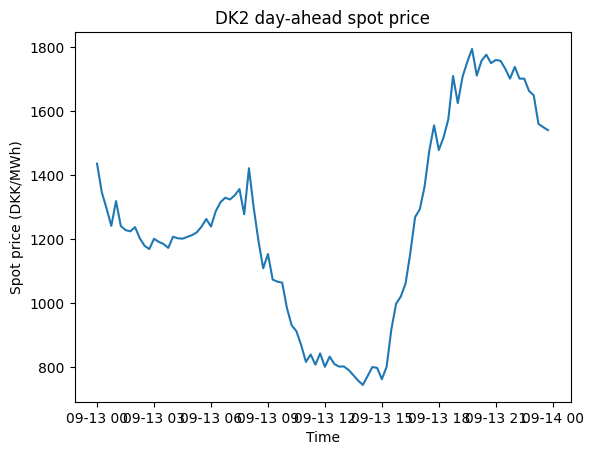

In [3]:
plt.plot(prices["TimeDK"], prices["DayAheadPriceDKK"])
plt.xlabel("Time")
plt.ylabel("Spot price (DKK/MWh)")
plt.title("DK2 day-ahead spot price")
plt.show()

In [4]:
wind = pd.read_csv("data/dk2_wind.csv", parse_dates=["Minutes5DK"])
wind["TotalWindPower"] = wind["OffshoreWindPower"] + wind["OnshoreWindPower"]
wind.head()

,Minutes5UTC,Minutes5DK,PriceArea,ProductionLt100MW,ProductionGe100MW,OffshoreWindPower,OnshoreWindPower,SolarPower,ExchangeGreatBelt,ExchangeGermany,ExchangeNetherlands,ExchangeGreatBritain,ExchangeNorway,ExchangeSweden,BornholmSE4,TotalWindPower
0,2026-09-13 21:55:00,2026-09-13 23:55:00,DK2,126.169998,202.089996,223.369995,125.320000,0.00,178.250000,76.529999,NaN,NaN,NaN,376.769989,29.280001,348.689995
1,2026-09-13 21:50:00,2026-09-13 23:50:00,DK2,125.959999,202.089996,204.179993,124.550003,0.00,180.619995,73.459999,NaN,NaN,NaN,394.019989,29.150000,328.729996
2,2026-09-13 21:45:00,2026-09-13 23:45:00,DK2,127.510002,202.089996,194.479996,124.820000,0.00,183.020004,89.230003,NaN,NaN,NaN,368.769989,29.420000,319.299996
3,2026-09-13 21:40:00,2026-09-13 23:40:00,DK2,126.029999,202.089996,175.389999,123.750000,0.00,191.039993,91.089996,NaN,NaN,NaN,378.130005,16.969999,299.139999
4,2026-09-13 21:35:00,2026-09-13 23:35:00,DK2,122.190002,202.080002,136.330002,122.440002,0.33,180.539993,102.400002,NaN,NaN,NaN,394.570007,-0.160000,258.770004


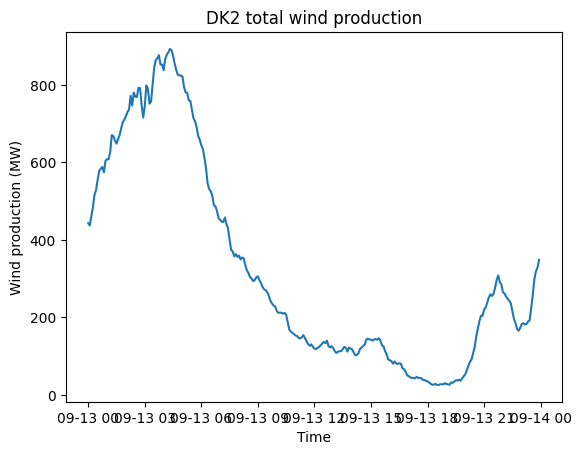

In [5]:
plt.plot(wind["Minutes5DK"], wind["TotalWindPower"])
plt.xlabel("Time")
plt.ylabel("Wind production (MW)")
plt.title("DK2 total wind production")
plt.show()

In [6]:
print("Price date range:", prices["TimeDK"].min(), "to", prices["TimeDK"].max())
print("Wind date range:", wind["Minutes5DK"].min(), "to", wind["Minutes5DK"].max())

Price date range: 2026-09-13 00:00:00 to 2026-09-13 23:45:00
Wind date range: 2026-09-13 00:00:00 to 2026-09-13 23:55:00


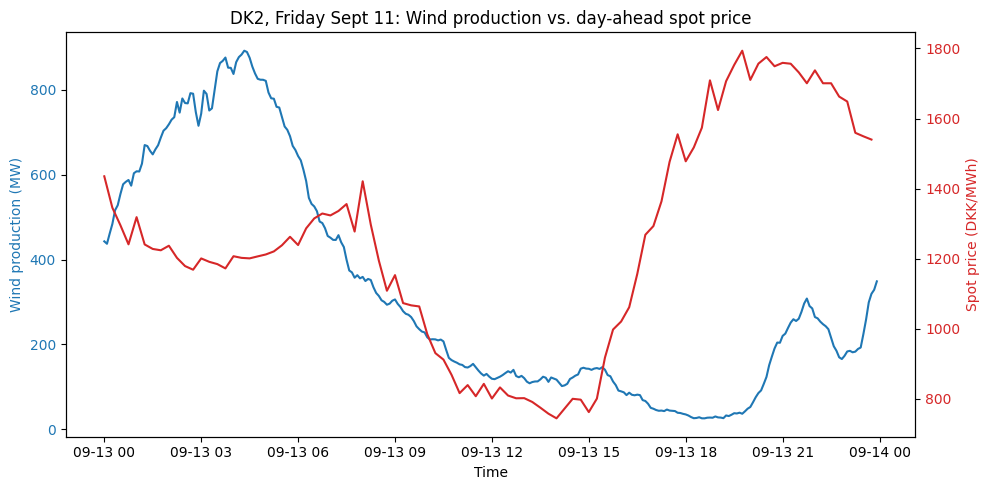

In [7]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(wind["Minutes5DK"], wind["TotalWindPower"], color="tab:blue", label="Wind production (MW)")
ax1.set_xlabel("Time")
ax1.set_ylabel("Wind production (MW)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(prices["TimeDK"], prices["DayAheadPriceDKK"], color="tab:red", label="Spot price (DKK/MWh)")
ax2.set_ylabel("Spot price (DKK/MWh)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("DK2, Friday Sept 11: Wind production vs. day-ahead spot price")
fig.tight_layout()
plt.savefig("data/wind_vs_price.png")
plt.show()